# Austo Motor Company: Data-Driven Analysis of Vehicle Preferences and Marketing Strategy

# Background:

Austo Motor Company is a leading automobile manufacturer specializing in SUVs, Sedans, and Hatchbacks. In a recent board meeting, concerns were raised regarding the efficiency of the company’s marketing campaigns and its alignment with customer preferences. To address this, the board engaged the Data Science team to analyze customer and purchase data in order to identify patterns, preferences, and potential opportunities to improve marketing effectiveness and sales strategy.

# Objective:

* To assess the influence of profession, gender, age, and household income on customer's vehicle choice and price.
* To evaluate how loans and dual-income households impact spending patterns.
* To provide actionable insights for targeted marketing, product positioning, and sales optimization.

# Data Description:

# Importing the necessary libraries:

In [1]:
# Libraries to help with reading, manipulating and visualizing the data:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

# Loading the dataset:

In [2]:
austo_df = pd.read_csv("data/austo_automobile.csv")

In [3]:
# copying data to another variable to avoid any changes to original data
austo_customers_df = austo_df.copy()

In [4]:
print("The austo_automobile dataset has", austo_df.shape[0], "rows and", austo_df.shape[1], "columns.")

The austo_automobile dataset has 1581 rows and 14 columns.


In [5]:
# looking at head (5 observations)
austo_df.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV


In [6]:
austo_df.tail()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
1576,22,Male,Salaried,Single,Graduate,2,No,Yes,No,33300,0.0,33300,27000,Hatchback
1577,22,Male,Business,Married,Graduate,4,No,No,No,32000,NaN,32000,31000,Hatchback
1578,22,Male,Business,Single,Graduate,2,No,Yes,No,32900,0.0,32900,30000,Hatchback
1579,22,Male,Business,Married,Graduate,3,Yes,Yes,No,32200,NaN,32200,24000,Hatchback
1580,22,Male,Salaried,Married,Graduate,4,No,No,No,31600,0.0,31600,31000,Hatchback


In [7]:
austo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.0+ KB


* The dataset consists of 1,581 observations and 14 variables, with minimal missing data concentrated in the Gender and Partner_salary columns. 
* All numerical and categorical variables are stored using appropriate data types, indicating good overall data quality.

# Statistical Summary of the dataset:

In [8]:
austo_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1581.0,31.922201,8.425978,22.0,25.0,29.0,38.0,54.0
No_of_Dependents,1581.0,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Salary,1581.0,60392.220114,14674.825044,30000.0,51900.0,59500.0,71800.0,99300.0
Partner_salary,1475.0,20225.559322,19573.149277,0.0,0.0,25600.0,38300.0,80500.0
Total_salary,1581.0,79625.996205,25545.857768,30000.0,60500.0,78000.0,95900.0,171000.0
Price,1581.0,35597.722960,13633.636545,18000.0,25000.0,31000.0,47000.0,70000.0


* Majority of the customers fall in the age group between 25 and 38 with an average age of 32.
* The stats indicate that there could be many unemployed partners.
* The price ranges are  distributed from 18000 dollars to 70000 dollars indicating a wide distribution.

# Data Cleaning:

### Handling Missing Values:

In [9]:
austo_df['Gender'].value_counts()

Male      1199
Female     327
Femal        1
Femle        1
Name: Gender, dtype: int64

It is observed that the spelling for female has been inputted wrongly, which needs to be replaced appropriately.

In [10]:
austo_df['Gender'] = austo_df['Gender'].replace({'Femal' : 'Female','Femle' : 'Female'})

In [11]:
austo_df['Gender'].value_counts(dropna=False)

Male      1199
Female     329
NaN         53
Name: Gender, dtype: int64

The typos are eliminated and the categories are standardized. 

In [12]:
austo_df['Gender'].isnull().sum()

53

In [13]:
austo_df['Gender'].mode()[0]

'Male'

In [14]:
austo_df['Gender'].fillna(austo_df['Gender'].mode()[0],inplace=True)

The Gender field with missing values are inputted with the mode of the Gender column as that is the widely used method to handle the missing categorical values.

In [15]:
austo_df['Gender'].isnull().sum()

0

In [16]:
#To check if the records for which the partner is not working are rightly recorded with no salary value:
austo_df.loc[(austo_df['Partner_working'] == 'No') &  (austo_df['Partner_salary'] > 0), ['Partner_working', 'Partner_salary']]


,Partner_working,Partner_salary


In [17]:
# 1. Set partner salary to 0 where partner is not working
austo_df.loc[austo_df['Partner_working'] == 'No', 'Partner_salary'] = 0

# 2. Compute median partner salary for working partners
median_partner_salary = austo_df.loc[austo_df['Partner_working'] == 'Yes','Partner_salary'].median()

# 3. Input missing salaries for working partners
austo_df.loc[(austo_df['Partner_working'] == 'Yes') & (austo_df['Partner_salary'].isnull()),'Partner_salary'] = median_partner_salary


Median was used instead of mean for inputing missing partner salary values because income distributions was typically right-skewed and contain outliers. Median inputation is more robust and prevents artificial inflation of household income.

In [18]:
austo_df['Total_salary'] = austo_df['Salary'] + austo_df['Partner_salary']


In [19]:
austo_df['Partner_salary'].isnull().sum()


0

In [20]:
austo_df.isnull().sum()

Age                 0
Gender              0
Profession          0
Marital_status      0
Education           0
No_of_Dependents    0
Personal_loan       0
House_loan          0
Partner_working     0
Salary              0
Partner_salary      0
Total_salary        0
Price               0
Make                0
dtype: int64

In [21]:
austo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1581 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1581 non-null   float64
 11  Total_salary      1581 non-null   float64
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 173.0+ KB


### Checking inconsistencies in categorical fields:

In [22]:
cat_cols = ['Profession', 'Marital_status', 'Education','Personal_loan', 'House_loan', 'Partner_working', 'Make']

for col in cat_cols:
    print(col)
    print(austo_df[col].value_counts())
    print('-' * 40)


Profession
Salaried    896
Business    685
Name: Profession, dtype: int64
----------------------------------------
Marital_status
Married    1443
Single      138
Name: Marital_status, dtype: int64
----------------------------------------
Education
Post Graduate    985
Graduate         596
Name: Education, dtype: int64
----------------------------------------
Personal_loan
Yes    792
No     789
Name: Personal_loan, dtype: int64
----------------------------------------
House_loan
No     1054
Yes     527
Name: House_loan, dtype: int64
----------------------------------------
Partner_working
Yes    868
No     713
Name: Partner_working, dtype: int64
----------------------------------------
Make
Sedan        702
Hatchback    582
SUV          297
Name: Make, dtype: int64
----------------------------------------


The fields with categorical records are checked for any inconsistencies in the entered values.

### Checking for the presence of duplicate records:

In [23]:
austo_df.duplicated().sum()

0

# Exploratory Data Analysis:

# Univariate Analysis

### Distribution of Customers by Gender

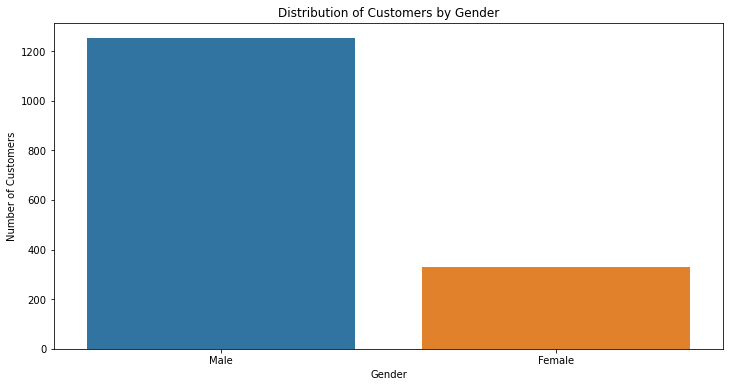

In [100]:
sns.countplot(data=austo_df, x='Gender')
plt.title('Distribution of Customers by Gender')
plt.ylabel('Number of Customers')
plt.show()

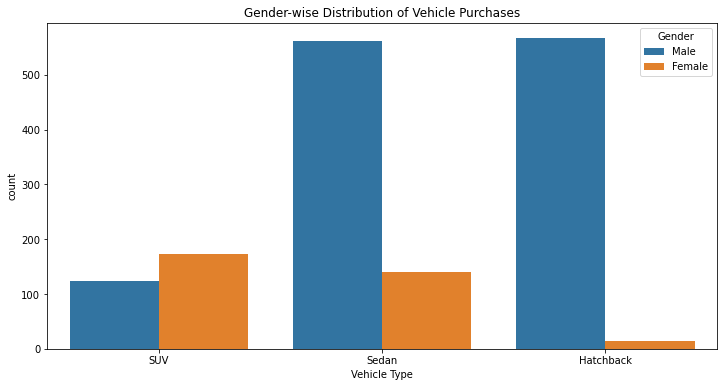

In [25]:
sns.countplot(data=austo_df, x='Make', hue='Gender')
plt.title('Gender-wise Distribution of Vehicle Purchases')
plt.xlabel('Vehicle Type')
plt.show()

In [26]:
pd.crosstab(austo_df['Gender'], austo_df['Make'], normalize='index') * 100

Make,Hatchback,SUV,Sedan
Gender,,,
Female,4.559271,52.583587,42.857143
Male,45.287540,9.904153,44.808307


**Observations:**
* Gender-wise analysis reveals a clear differentiation in vehicle preferences. 
* Female customers show a strong preference for SUVs, with over 52% of purchases falling in this category, while Hatchbacks account for less than 5% of their purchases. 
* In contrast, male customers exhibit a more evenly distributed preference between Hatchbacks and Sedans, each contributing approximately 45% of purchases, with SUVs forming a relatively small share. 
* These findings highlight the importance of gender-sensitive marketing strategies and suggest that vehicle positioning may benefit from gender-specific targeting.


### Distribution of Vehicle Types Purchased

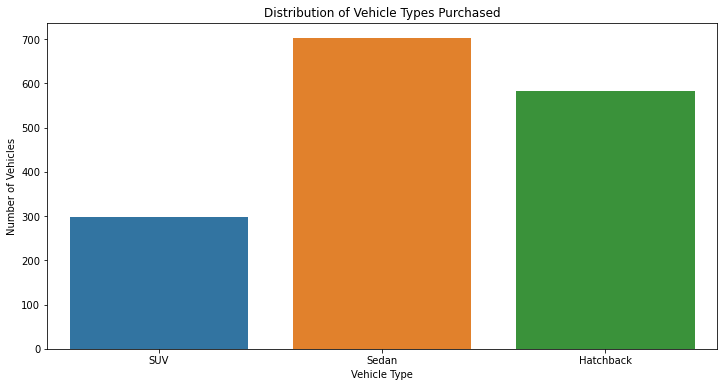

Sedan        44.402277
Hatchback    36.812144
SUV          18.785579
Name: Make, dtype: float64

In [27]:
sns.countplot(data=austo_df, x='Make')
plt.title('Distribution of Vehicle Types Purchased')
plt.ylabel('Number of Vehicles')
plt.xlabel('Vehicle Type')
plt.show()

austo_df['Make'].value_counts(normalize=True) * 100

**Observations:**
* The univariate analysis of vehicle types reveals that the overall demand is skewed toward Sedans and Hatchbacks, which together account for over 80% of total purchases.
* Sedans dominate customer demand, accounting for approximately 44% of total purchases. 
* Hatchbacks follow closely with nearly 37%, highlighting a strong market for compact and budget-friendly vehicles. 
* SUVs, in contrast, represent a smaller segment at around 19%, suggesting that while present, they cater to a more niche customer base. 

### Distribution of Customers by Profession

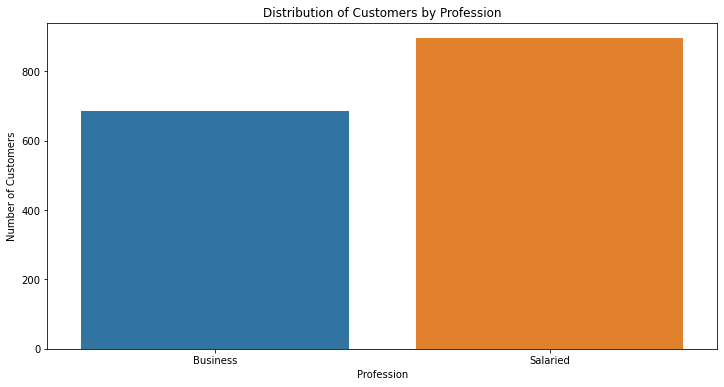

Salaried    56.672992
Business    43.327008
Name: Profession, dtype: float64

In [29]:
sns.countplot(data=austo_df, x='Profession')
plt.title('Distribution of Customers by Profession')
plt.xlabel('Profession')
plt.ylabel('Number of Customers')
plt.show()

austo_df['Profession'].value_counts(normalize=True) * 100


**Observations:**
* The univariate analysis of profession shows a relatively balanced distribution of customers, with salaried individuals accounting for approximately 57% of purchases and business professionals contributing about 43%.
* This indicates that Austo Motor Company serves a diverse professional base, rather than dependence on a single professional segment.
* This reduces business risk associated with economic downturns affecting one employment category.

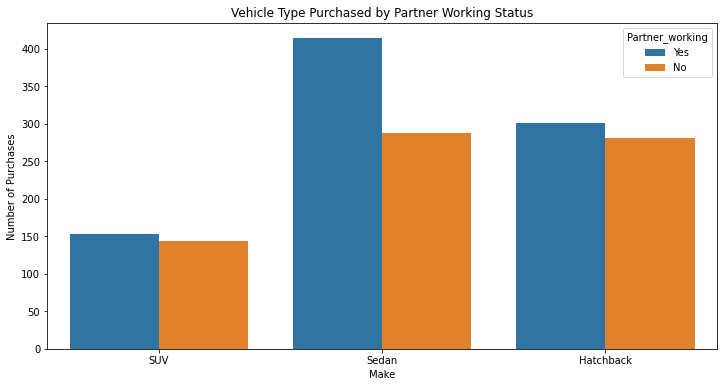

In [30]:
sns.countplot(data=austo_df, x='Make', hue='Partner_working')
plt.title('Vehicle Type Purchased by Partner Working Status')
plt.ylabel('Number of Purchases')
plt.show()

### Distribution of Customer Age

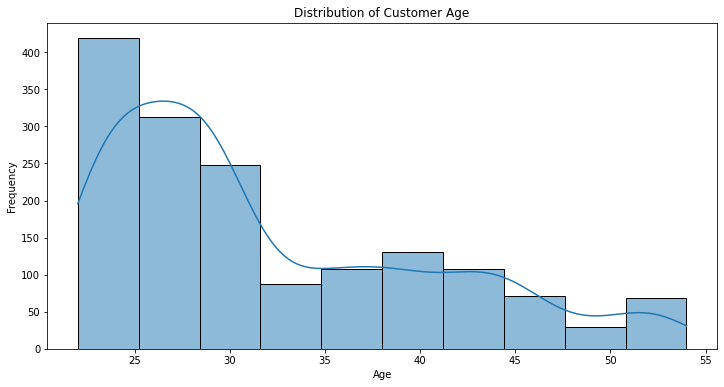

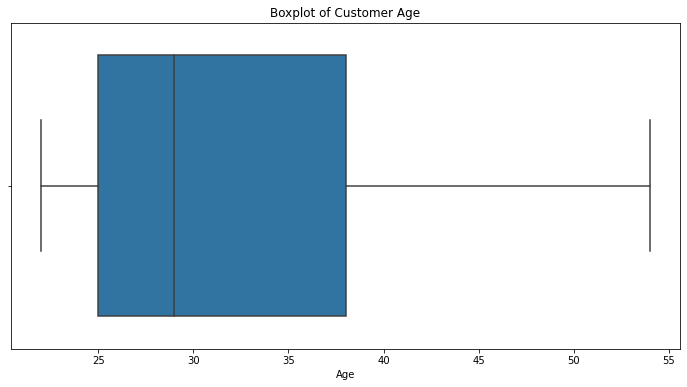

In [31]:
sns.histplot(austo_df['Age'], bins=10, kde=True)
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

sns.boxplot(x=austo_df['Age'])
plt.title('Boxplot of Customer Age')
plt.show()


**Observations:**
* The univariate analysis of customer age reveals that Austo Motor Company primarily serves a young-to-mid aged customer base. 
* With a median age of 29 years and a mean age of approximately 32 years, the distribution is slightly right-skewed, indicating fewer older customers. 
* The relatively narrow age spread suggests a focused target demographic, dominated by early and mid-career individuals.


### Distribution of Vehicle Prices

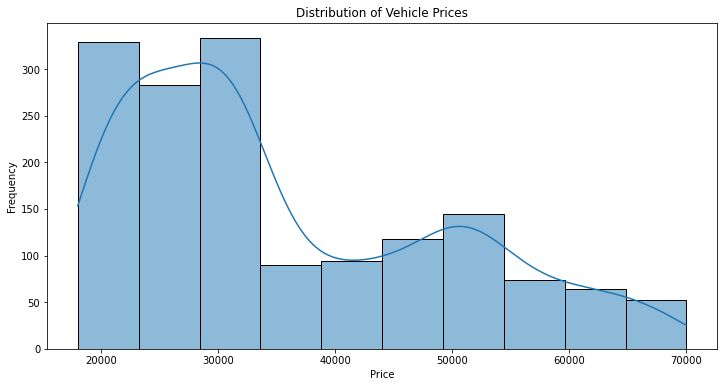

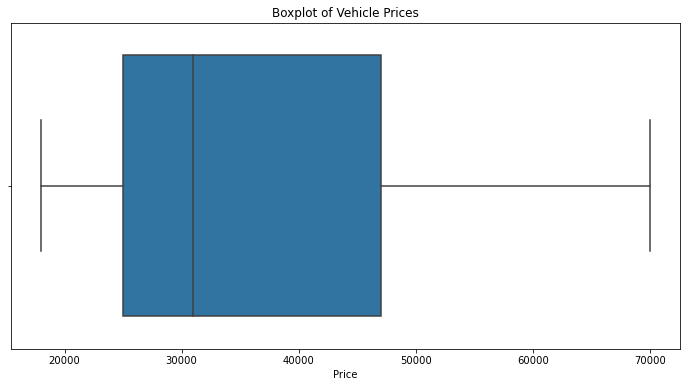

In [32]:
sns.histplot(austo_df['Price'], bins=10, kde=True)
plt.title('Distribution of Vehicle Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

sns.boxplot(x=austo_df['Price'])
plt.title('Boxplot of Vehicle Prices')
plt.show()

**Observations:**
* The univariate analysis of vehicle prices reveals a wide but right-skewed distribution. While prices range from 18,000 to 70,000, most customers operate within a lower-to-mid price band.
* The interquartile range shows 25% of purchases are priced below 25000 dollars,50% fall between 25000 and 47000 dollars and only 25% exceed 47,000 dollars.
* Overall, the pricing structure indicates clear segmentation, with volume driven largely by affordable and mid-range models.


### Distribution of Total Household Salary

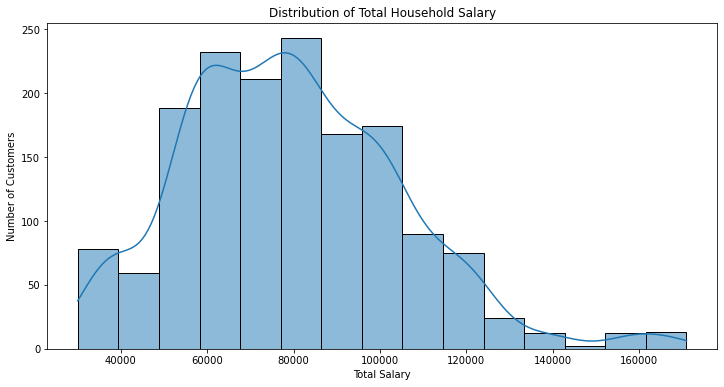

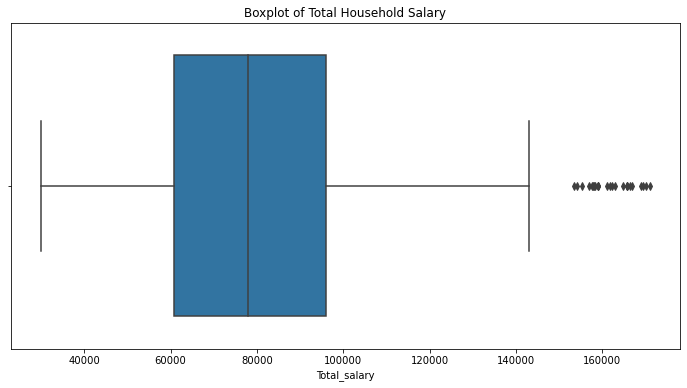

In [33]:
sns.histplot(austo_df['Total_salary'], bins=15, kde=True)
plt.title('Distribution of Total Household Salary')
plt.xlabel('Total Salary')
plt.ylabel('Number of Customers')
plt.show()

sns.boxplot(x=austo_df['Total_salary'])
plt.title('Boxplot of Total Household Salary')
plt.show()


**Observations:**
* The univariate analysis of total household salary indicates a moderately right-skewed distribution.
* Most customers fall within a middle-income bracket (25th–75th percentile: 60500–95900), while a smaller segment of higher-income households extends up to 171000. 
* This distribution reflects a diverse customer base, ranging from moderate- to high-income households, and provides a baseline for evaluating affordability and vehicle purchasing patterns.

### Distribution of Customers by Loan Status

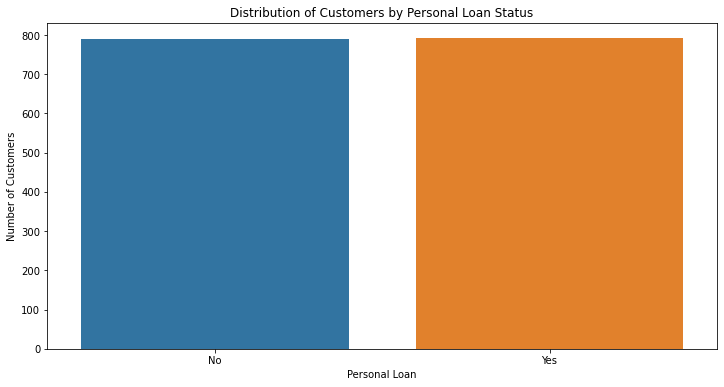

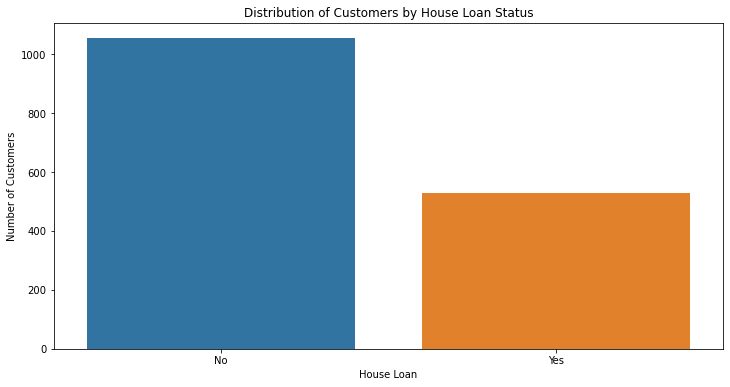

Personal Loan (% of Customers):
 Yes    50.094877
No     49.905123
Name: Personal_loan, dtype: float64

House Loan (% of Customers):
 No     66.666667
Yes    33.333333
Name: House_loan, dtype: float64


In [34]:
# Personal Loan Distribution
sns.countplot(data=austo_df, x='Personal_loan')
plt.title('Distribution of Customers by Personal Loan Status')
plt.xlabel('Personal Loan')
plt.ylabel('Number of Customers')
plt.show()

# House Loan Distribution
sns.countplot(data=austo_df, x='House_loan')
plt.title('Distribution of Customers by House Loan Status')
plt.xlabel('House Loan')
plt.ylabel('Number of Customers')
plt.show()

# Percentage distribution for precise reporting
personal_loan_percent = austo_df['Personal_loan'].value_counts(normalize=True) * 100
house_loan_percent = austo_df['House_loan'].value_counts(normalize=True) * 100

print("Personal Loan (% of Customers):\n", personal_loan_percent)
print("\nHouse Loan (% of Customers):\n", house_loan_percent)


### Distribution of Customers by Partner Working Status

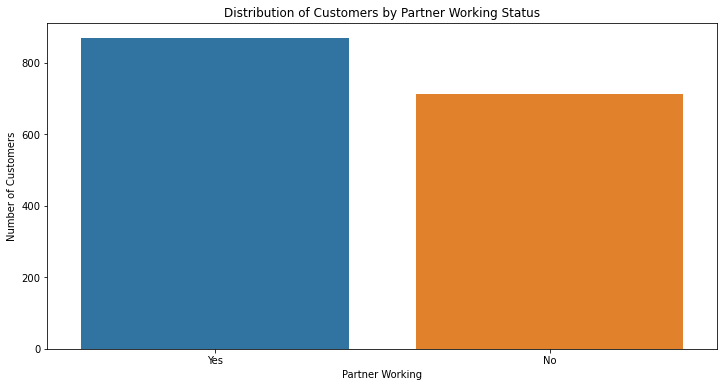

Partner Working (% of Customers):
 Yes    54.901961
No     45.098039
Name: Partner_working, dtype: float64


In [35]:
# Partner Working Status Distribution
sns.countplot(data=austo_df, x='Partner_working')
plt.title('Distribution of Customers by Partner Working Status')
plt.xlabel('Partner Working')
plt.ylabel('Number of Customers')
plt.show()

# Percentage distribution for reporting
partner_working_percent = austo_df['Partner_working'].value_counts(normalize=True) * 100
print("Partner Working (% of Customers):\n", partner_working_percent)


**Observations:**
* The univariate analysis of partner working status shows that approximately 55% of customers have a working partner, while 45% do not. 
* This indicates that Austo’s customer base includes a mix of dual-income and single-income households.

### Distribution of Number of Dependents

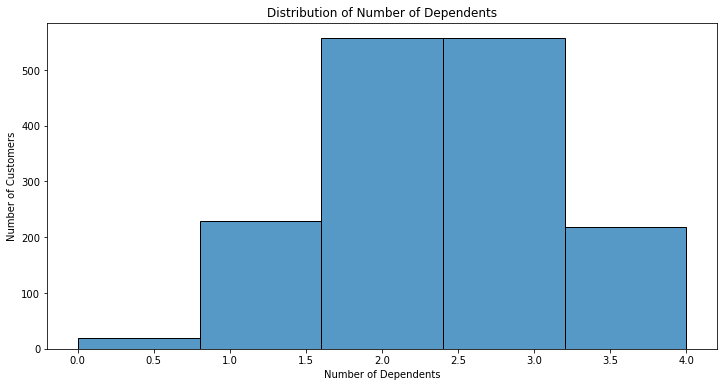

Number of Dependents (% of Customers):
 3    35.230867
2    35.230867
1    14.484503
4    13.788741
0     1.265022
Name: No_of_Dependents, dtype: float64


In [36]:
# Histogram to see distribution
sns.histplot(austo_df['No_of_Dependents'], bins=austo_df['No_of_Dependents'].nunique(), kde=False)
plt.title('Distribution of Number of Dependents')
plt.xlabel('Number of Dependents')
plt.ylabel('Number of Customers')
plt.show()

# Percentage distribution for reporting
dependents_percent = austo_df['No_of_Dependents'].value_counts(normalize=True) * 100
print("Number of Dependents (% of Customers):\n", dependents_percent)

**Observations:**
* The univariate analysis of the number of dependents reveals that most Austo customers support 2–3 dependents. 
* The household size distribution is relatively narrow, with a maximum of 4 dependents. 
* A small segment of customers has no dependents, suggesting a mix of single individuals or childless couples. 

# Bivariate Analysis:

### Vehicle Choice by Gender


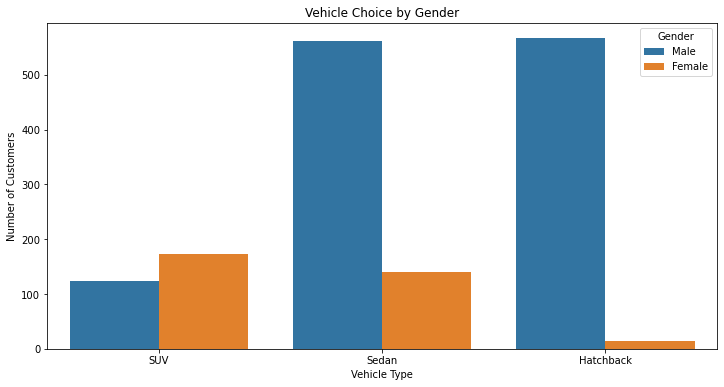

Make    Hatchback        SUV      Sedan
Gender                                 
Female   4.559271  52.583587  42.857143
Male    45.287540   9.904153  44.808307


In [37]:
sns.countplot(data=austo_df, x='Make', hue='Gender')
plt.title('Vehicle Choice by Gender')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Customers')
plt.show()

# Percentage table for reporting
gender_make_percent = pd.crosstab(austo_df['Gender'], austo_df['Make'], normalize='index') * 100
print(gender_make_percent)


**Observations**
* The bivariate analysis of Gender vs Vehicle Type reveals a pronounced difference in SUV preference. 
* Approximately 53% of female customers purchase SUVs compared to just 10% of male customers. 
* Male buyers, in contrast, predominantly prefer Hatchbacks and Sedans. 
* These findings indicate a strong gender-specific pattern in vehicle choice, providing an opportunity for Austo Motor Company to tailor marketing campaigns and promotions according to customer gender.

### Vehicle Choice by Profession

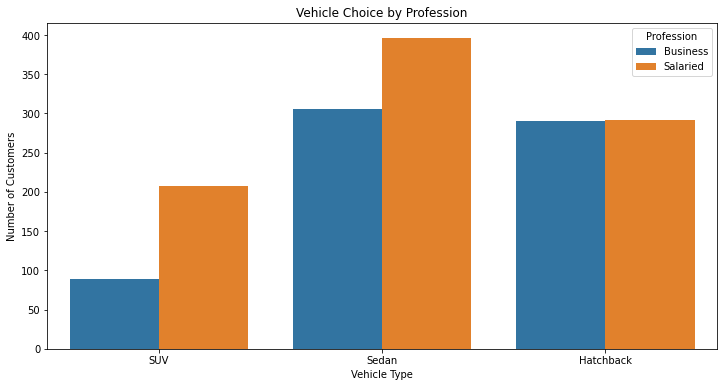

Make        Hatchback        SUV      Sedan
Profession                                 
Business    42.335766  12.992701  44.671533
Salaried    32.589286  23.214286  44.196429


In [38]:
sns.countplot(data=austo_df, x='Make', hue='Profession')
plt.title('Vehicle Choice by Profession')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Customers')
plt.show()

# Percentage table
profession_make_percent = pd.crosstab(austo_df['Profession'], austo_df['Make'], normalize='index') * 100
print(profession_make_percent)


**Observations**
* The bivariate analysis of Profession vs Vehicle Type indicates that Sedans are the most popular choice for both business and salaried customers, accounting for approximately 44% of purchases in each group. 
* Salaried individuals are nearly twice as likely as business professionals to purchase SUVs, suggesting that SUV marketing could be targeted toward this segment. 
* Conversely, Hatchbacks are more popular among business professionals, reflecting the appeal of practical and cost-efficient options. These insights can guide segment-specific marketing and inventory decisions.

### Vehicle Choice by Personal Loan Status

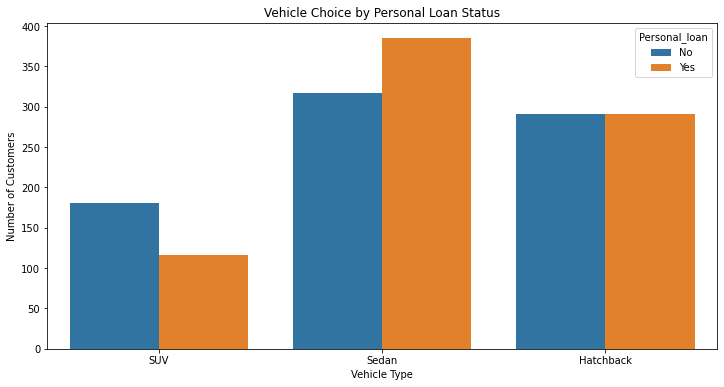

Make           Hatchback        SUV      Sedan
Personal_loan                                 
No             36.882129  22.940431  40.177440
Yes            36.742424  14.646465  48.611111


In [39]:
sns.countplot(data=austo_df, x='Make', hue='Personal_loan')
plt.title('Vehicle Choice by Personal Loan Status')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Customers')
plt.show()

# Percentage table
loan_make_percent = pd.crosstab(austo_df['Personal_loan'], austo_df['Make'], normalize='index') * 100
print(loan_make_percent)


**Observations:**
* The bivariate analysis of Personal Loan vs Vehicle Type reveals that customers with personal loans are more likely to purchase Sedans, compared to those without loans. 
* SUV purchases are less common among loan users than non-loan customers suggesting that higher-priced SUV adoption may be limited among financed buyers. 
* Hatchbacks maintain consistent popularity regardless of loan status, indicating their accessibility across both financed and self-financed segments. 
* These insights can inform credit product promotions and vehicle financing strategies.

### Vehicle Choice by Partner Working Status

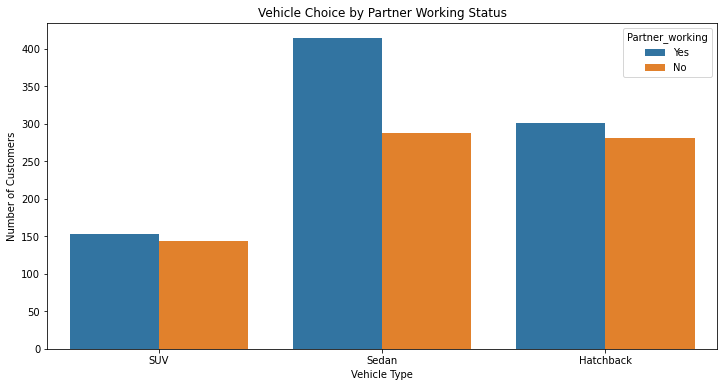

Make             Hatchback        SUV      Sedan
Partner_working                                 
No               39.410940  20.196353  40.392707
Yes              34.677419  17.626728  47.695853


In [40]:
sns.countplot(data=austo_df, x='Make', hue='Partner_working')
plt.title('Vehicle Choice by Partner Working Status')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Customers')
plt.show()

# Percentage table
partner_make_percent = pd.crosstab(austo_df['Partner_working'], austo_df['Make'], normalize='index') * 100
print(partner_make_percent)


**Observations:**
* The bivariate analysis of Partner Working vs Vehicle Type shows that dual-income households (partners working) are more likely to purchase Sedans compared to single-income households.
* Conversely, Hatchbacks are slightly more popular among single-income households than dual-income households.
* SUV adoption is moderate across both groups, with a slightly higher proportion among single-income households. 
* These insights suggest that dual-income households prioritize mid-range vehicles like Sedans, while budget-friendly Hatchbacks appeal more to single-income households, informing targeted marketing and pricing strategies.

### Price of Car purchase by Salary

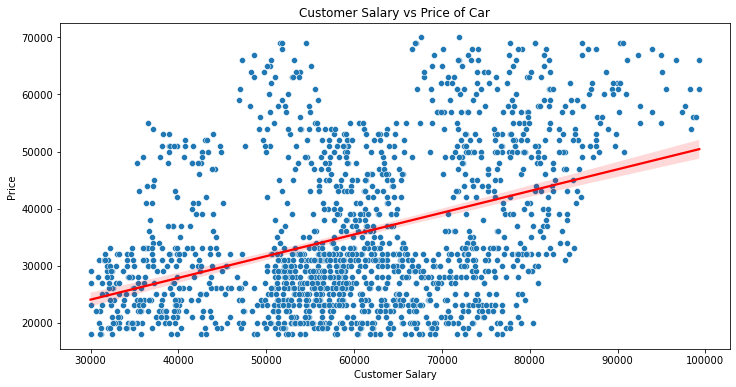

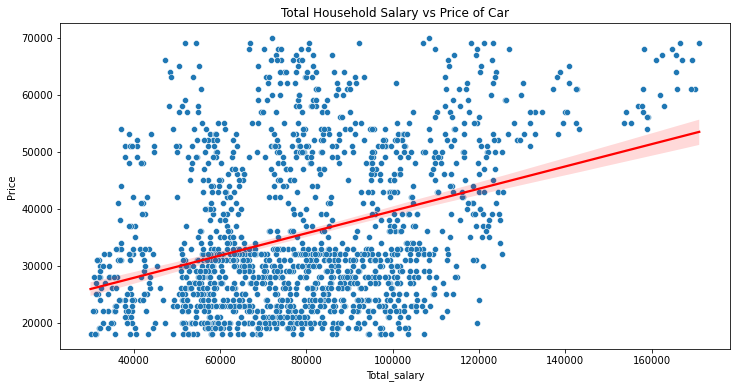

In [41]:
# Scatterplot + Regression for Salary vs Price
sns.scatterplot(data=austo_df, x='Salary', y='Price')
sns.regplot(data=austo_df, x='Salary', y='Price', scatter=False, color='red')
plt.title('Customer Salary vs Price of Car')
plt.xlabel('Customer Salary')
plt.ylabel('Price')
plt.show()

# Scatterplot + Regression for Total_salary vs Price
sns.scatterplot(data=austo_df, x='Total_salary', y='Price')
sns.regplot(data=austo_df, x='Total_salary', y='Price', scatter=False, color='red')
plt.title('Total Household Salary vs Price of Car')
plt.xlabel('Total_salary')
plt.ylabel('Price')

plt.show()



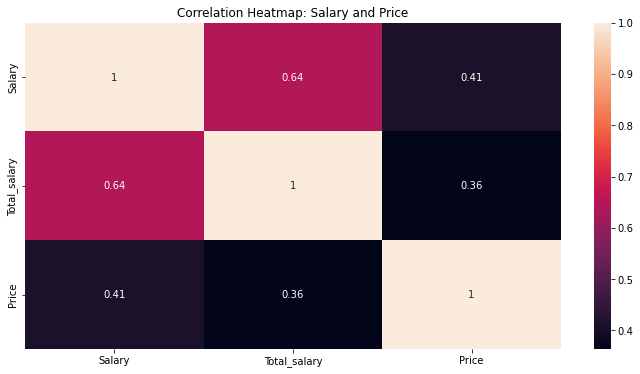

In [42]:
subset_cols = ['Salary', 'Total_salary', 'Price']
corr_subset = austo_df[subset_cols].corr()
sns.heatmap(corr_subset, annot=True, cbar=True)
plt.title('Correlation Heatmap: Salary and Price')
plt.show()


**Observations:**
* The bivariate analysis of Salary and Total Household Salary vs Price reveals a moderate positive relationship, with correlations of 0.41 and 0.36 respectively. 
* Higher individual and household incomes are associated with purchases of higher-priced vehicles, though the primary buyer’s salary appears slightly more predictive than total household income.
* These insights indicate that Austo Motor Company can tailor pricing strategies and marketing efforts according to customer income segments, while also considering other factors that influence purchasing behaviour.


### Average Car Price with respect to Age

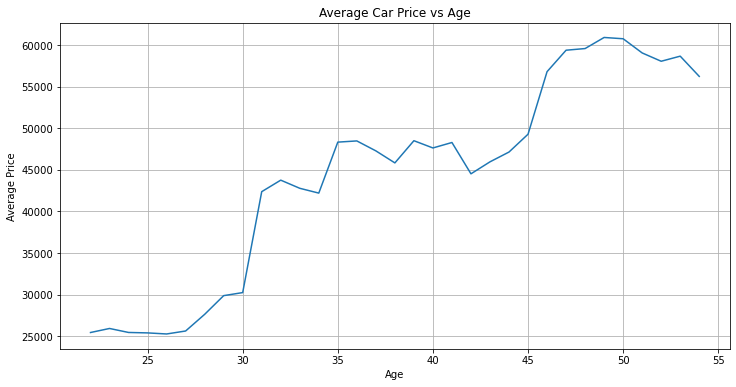

In [43]:
# Group by Age and compute mean Price
age_price = austo_df.groupby('Age')['Price'].mean().reset_index()

# Plot line chart
plt.plot(age_price['Age'], age_price['Price'])
plt.title('Average Car Price vs Age')
plt.xlabel('Age')
plt.ylabel('Average Price')
plt.grid(True)
plt.show()


**Observations:**
* The line plot analysis of Age vs Car Price indicates a clear positive trend in vehicle spending as customers age. 
* Younger customers typically purchase lower-priced cars while middle-aged customers progressively buy higher-priced vehicles, peaking around 45–50 years. 
* These insights suggest that Austo Motor Company can tailor pricing and promotional strategies according to age segments, targeting younger customers with entry-level models and middle-aged customers with premium options.

### Car Price by Number of Dependents

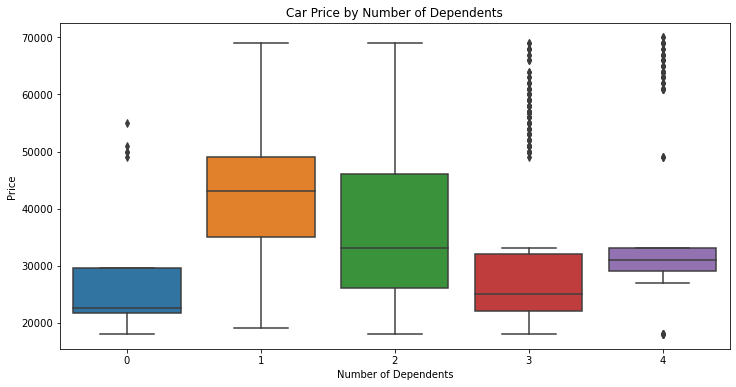

In [44]:
#Dependents vs price:
sns.boxplot(data=austo_df, x='No_of_Dependents', y='Price')
plt.title('Car Price by Number of Dependents')
plt.xlabel('Number of Dependents')
plt.ylabel('Price')
plt.show()


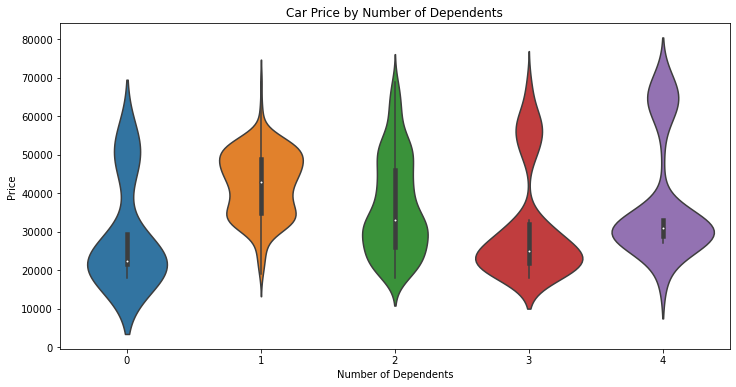

In [45]:
#Dependents vs price:
sns.violinplot(data=austo_df, x='No_of_Dependents', y='Price')
plt.title('Car Price by Number of Dependents')
plt.xlabel('Number of Dependents')
plt.ylabel('Price')
plt.show()


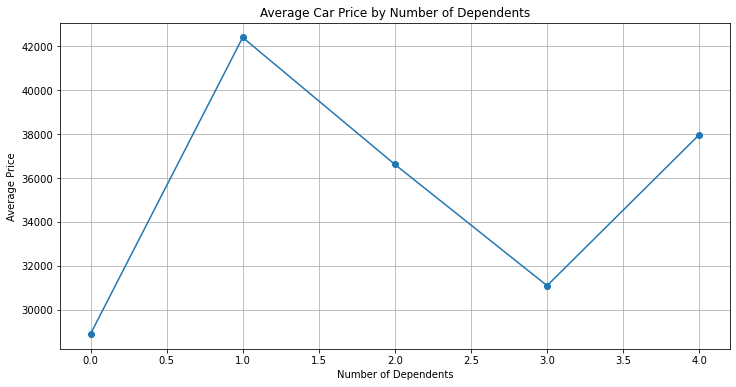

In [46]:
dependents_price = austo_df.groupby('No_of_Dependents')['Price'].mean().reset_index()
plt.plot(dependents_price['No_of_Dependents'], dependents_price['Price'], marker='o')
plt.title('Average Car Price by Number of Dependents')
plt.xlabel('Number of Dependents')
plt.ylabel('Average Price')
plt.grid(True)
plt.show()


**Observations:**
* The analysis of Number of Dependents vs Car Price reveals a non-linear relationship. 
* While mean prices suggest high spending for households with 1 or 4 dependents, these are influenced by a few outliers purchasing premium vehicles.
* Median prices show a more robust trend, with larger households (4 dependents) generally spending more than smaller households (0–2 dependents), and middle-sized families (2–3 dependents) preferring mid-range cars.
* These findings indicate that Austo Motor Company can target premium vehicles to small and large families with high spending potential, while offering mid-range options for typical mid-sized households, ensuring marketing strategies are both accurate and segment-specific.

### Car Price Distribution by Gender

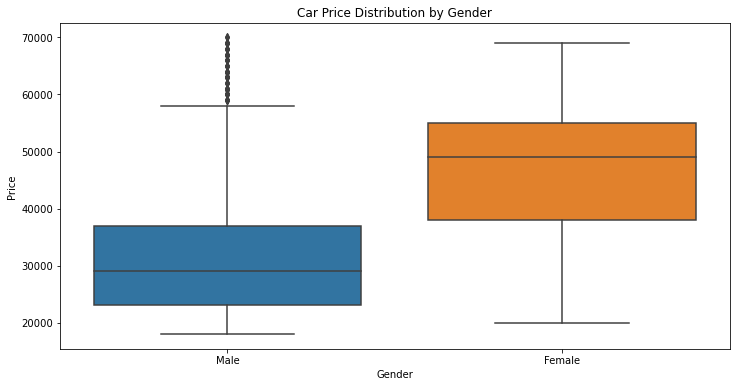

In [47]:
#Gender vs price:
sns.boxplot(data=austo_df, x='Gender', y='Price')
plt.title('Car Price Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Price')
plt.show()


**Observations:**
* The analysis of vehicle price by gender reveals a significant disparity in spending behavior.
* Female customers exhibit substantially higher typical spending, with a median car price of 49,000 compared to 29,000 for male customers.
* Despite representing a smaller proportion of the customer base, female buyers consistently purchase higher-priced vehicles, indicating strong potential as a premium customer segment.
* Male buyers, while more numerous, tend to be more price-sensitive and concentrated in the lower to mid-price range.
* These insights suggest that Austo Motor Company can drive higher revenue by tailoring premium offerings and targeted marketing campaigns toward female customers, while positioning budget-friendly options for male buyers.

### Car Price Distribution by Vehicle Type

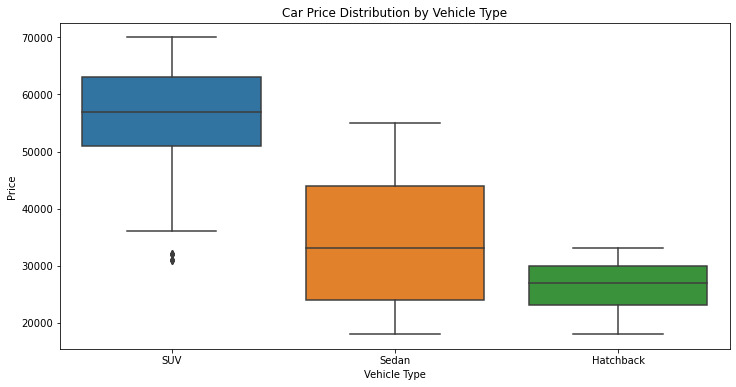

In [48]:
sns.boxplot(data=austo_df, x='Make', y='Price')
plt.title('Car Price Distribution by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Price')
plt.show()


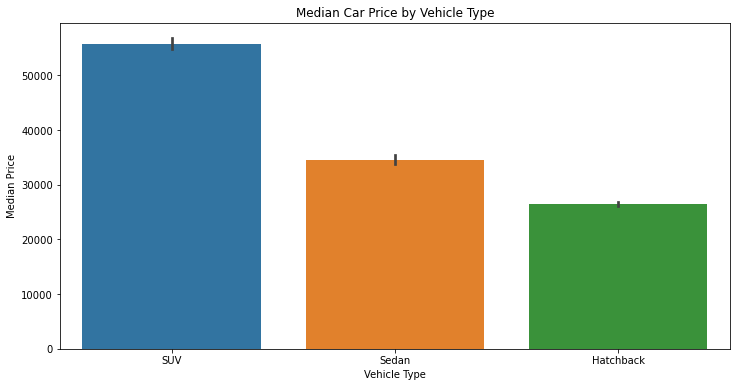

In [49]:
sns.barplot(data=austo_df,x='Make',y='Price')

plt.title('Median Car Price by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Median Price')
plt.show()


**Observations:**
* The analysis of car prices by vehicle type reveals strong and well-defined price segmentation.
* Hatchbacks occupy the entry-level segment with a median price of 27,000 and limited price variability. 
* Sedans form the mid-range category, serving the broadest customer base and exhibiting significant price flexibility.
* SUVs clearly dominate the premium segment, with a median price of 57,000 and a high minimum price threshold, indicating strong willingness to pay among SUV buyers.
* These findings confirm that vehicle type is a primary determinant of price and should remain a key axis for marketing and pricing strategies at Austo Motor Company.

### Car Price Distribution by Personal Loan Status

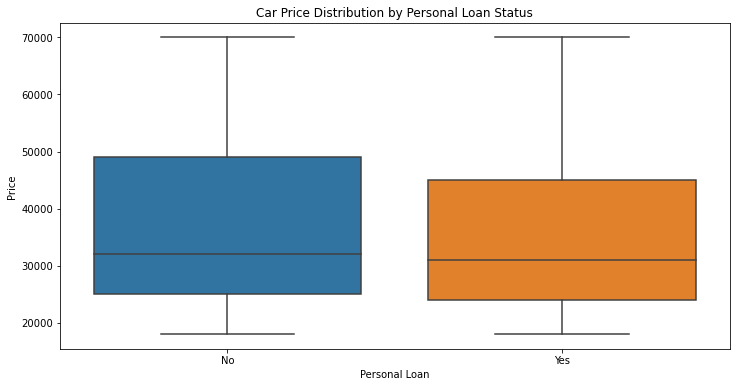

In [50]:
#Personal loan vs Price
sns.boxplot(data=austo_df, x='Personal_loan', y='Price')
plt.title('Car Price Distribution by Personal Loan Status')
plt.xlabel('Personal Loan')
plt.ylabel('Price')
plt.show()


**Observations:**
* The analysis of car prices by personal loan status reveals that customers who have taken a personal loan tend to purchase slightly lower-priced vehicles.
* While loans enable access to vehicle ownership, they do not appear to significantly drive premium car purchases.
* Non-loan buyers exhibit greater price variability, indicating higher spending flexibility and a stronger presence in premium segments. 
* These insights suggest that personal loans primarily serve as an accessibility tool rather than a premium upselling lever.

### Car Price Distribution by Partner Working Status

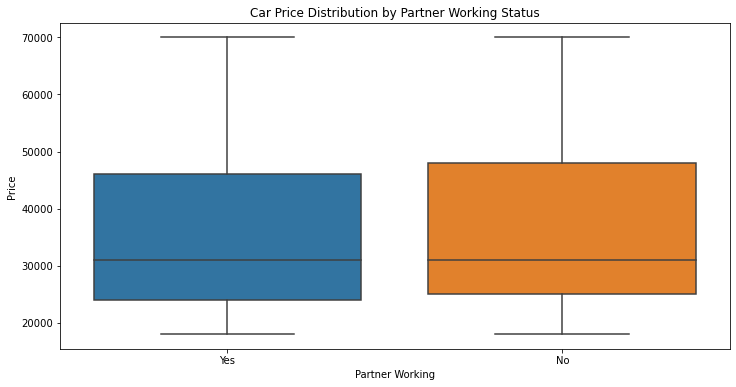

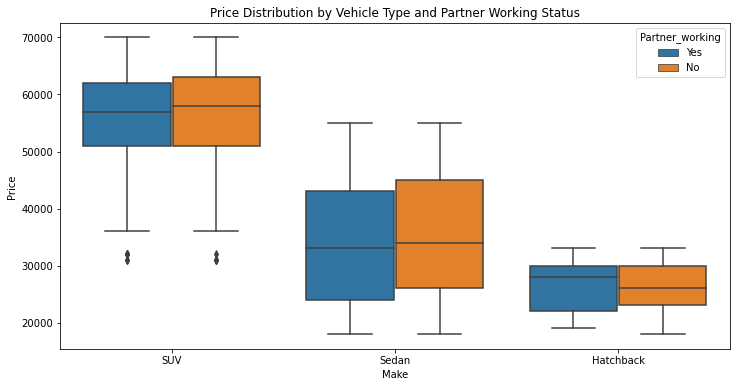

Make,Hatchback,SUV,Sedan
Partner_working,,,
No,26323.843416,56173.611111,35354.166667
Yes,26614.617940,55496.732026,34082.125604


In [92]:
#Partner_working vs Price:

sns.boxplot(data=austo_df, x='Partner_working', y='Price')
plt.title('Car Price Distribution by Partner Working Status')
plt.xlabel('Partner Working')
plt.ylabel('Price')
plt.show()

sns.boxplot(data=austo_df, x='Make', y='Price', hue='Partner_working')
plt.title('Price Distribution by Vehicle Type and Partner Working Status')
plt.show()

austo_df.groupby(['Partner_working', 'Make'])['Price'].mean().unstack()


**Observation:**
* The analysis of car prices by partner working status shows that dual-income households do not typically spend more on vehicles. 
* Both groups exhibit an almost identical median car price of 31,000, indicating similar purchase behavior.
* While households with a working partner contribute a higher total revenue, this is driven by a larger customer base rather than higher per-vehicle spending. 
* These findings suggest that car purchasing decisions remain conservative even among dual-income households, highlighting the need for targeted premium upselling strategies rather than assuming higher willingness to pay.

### Vehicle Price Distribution by Profession

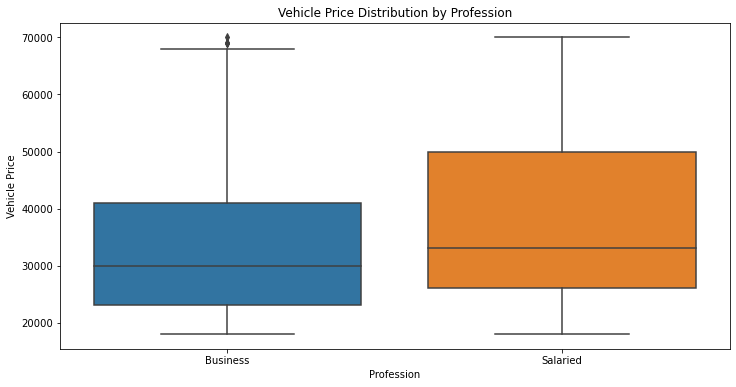

In [52]:
sns.boxplot(data=austo_df, x='Profession', y='Price')
plt.title('Vehicle Price Distribution by Profession')
plt.ylabel('Vehicle Price')
plt.xlabel('Profession')
plt.show()

**Observation:**
* Salaried customers demonstrate a higher willingness and capacity to spend on automobiles compared to business owners. 
* Despite similar price ranges and variability, salaried professionals tend to allocate a higher budget toward vehicle purchases, making them a key target segment for mid-to-high priced models.

# Answers to Key Questions (Multivariate Analysis) :

### Average Vehicle Price by Age Group and Vehicle Type

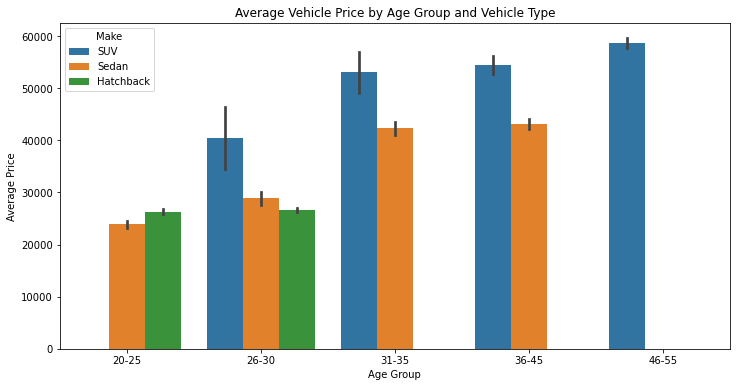

In [53]:
age_bins = [20, 25, 30, 35, 45, 55]
age_labels = ['20-25', '26-30', '31-35', '36-45', '46-55']

austo_df['Age_Group'] = pd.cut(austo_df['Age'],bins=age_bins,labels=age_labels,right=True)

sns.barplot(data=austo_df,x='Age_Group',y='Price',hue='Make')
plt.title('Average Vehicle Price by Age Group and Vehicle Type')
plt.ylabel('Average Price')
plt.xlabel('Age Group')
plt.show()


**Observations:**
* Vehicle preference and spending are strongly influenced by life stage rather than gender alone. 
* Entry-level buyers (20–25) prioritize affordability, while SUV adoption begins in the late 20s and becomes dominant after 30. 
* Mid-career customers (36–45) represent the most lucrative segment, consistently purchasing higher-priced SUVs.
* By the age of 46, customer preferences consolidate entirely around premium SUVs.

### **1. Do men tend to prefer SUVs more compared to women?**

**Observation:**

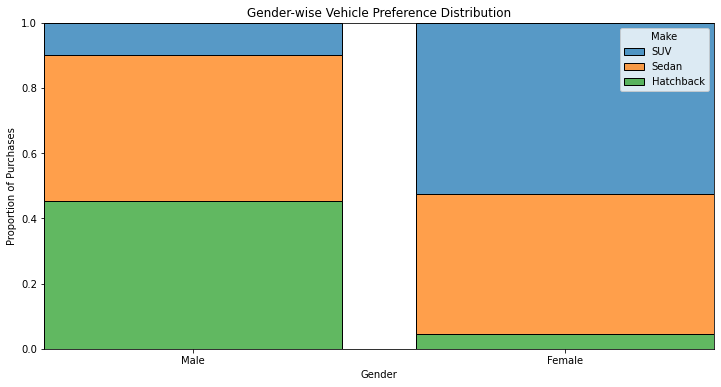

Make    Hatchback        SUV      Sedan
Gender                                 
Female   4.559271  52.583587  42.857143
Male    45.287540   9.904153  44.808307


In [78]:
sns.histplot(data=austo_df,x='Gender',hue='Make', shrink=0.8, multiple = 'fill')
plt.title('Gender-wise Vehicle Preference Distribution')
plt.ylabel('Proportion of Purchases')
plt.xlabel('Gender')
plt.show()


# Percentage table for reporting
gender_make_percent = pd.crosstab(austo_df['Gender'], austo_df['Make'], normalize='index') * 100
print(gender_make_percent)

Analysis of gender-wise vehicle preference indicates that men do not prefer SUVs more than women. The SUV preference is significantly higher among female customers. Over 52% of female buyers opted for SUVs, whereas less than 10% of male buyers purchased SUVs. Male customers predominantly preferred hatchbacks and sedans.

### **2. What is the likelihood of a salaried person buying a Sedan?**

**Observation:**

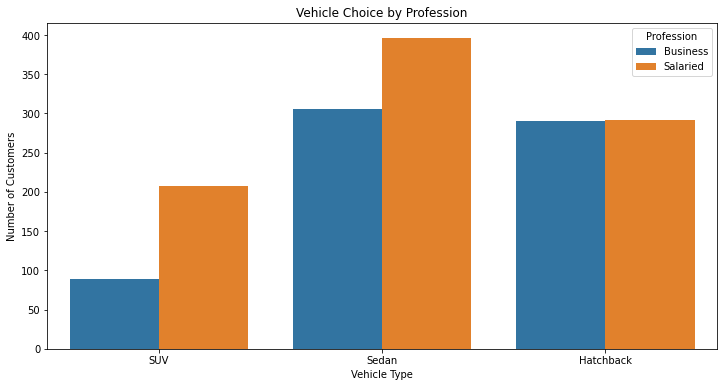

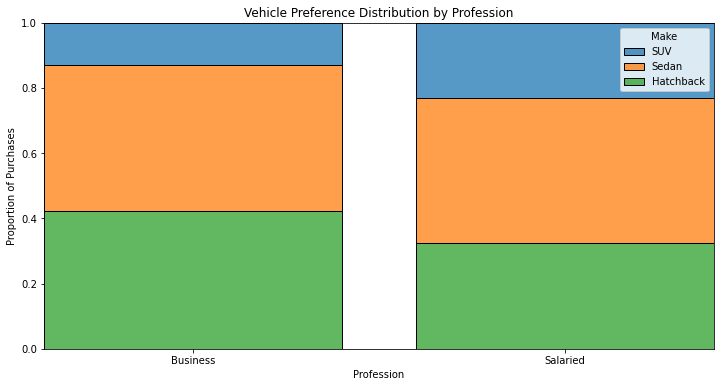

Make        Hatchback        SUV      Sedan
Profession                                 
Business    42.335766  12.992701  44.671533
Salaried    32.589286  23.214286  44.196429


In [81]:
sns.countplot(data=austo_df, x='Make', hue='Profession')
plt.title('Vehicle Choice by Profession')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Customers')
plt.show()


sns.histplot(data=austo_df,x='Profession',hue='Make',multiple='fill',shrink=0.8)
plt.title('Vehicle Preference Distribution by Profession')
plt.ylabel('Proportion of Purchases')
plt.xlabel('Profession')
plt.show()

# Percentage table
profession_make_percent = pd.crosstab(austo_df['Profession'], austo_df['Make'], normalize='index') * 100
print(profession_make_percent)

Analysis of profession-wise vehicle preference indicates that salaried individuals show a high likelihood of purchasing Sedans. Approximately 44% of salaried customers opted for Sedans, making it the most preferred vehicle type within this group.

### 3. What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale? 

**Observation:**

In [83]:
salaried_male_df = austo_df[(austo_df['Gender'] == 'Male') & (austo_df['Profession'] == 'Salaried')]
salaried_male_percent = (pd.crosstab(salaried_male_df['Gender'], salaried_male_df['Make'], normalize='index') * 100)
salaried_male_percent

Make,Hatchback,SUV,Sedan
Gender,,,
Male,41.220238,13.392857,45.386905


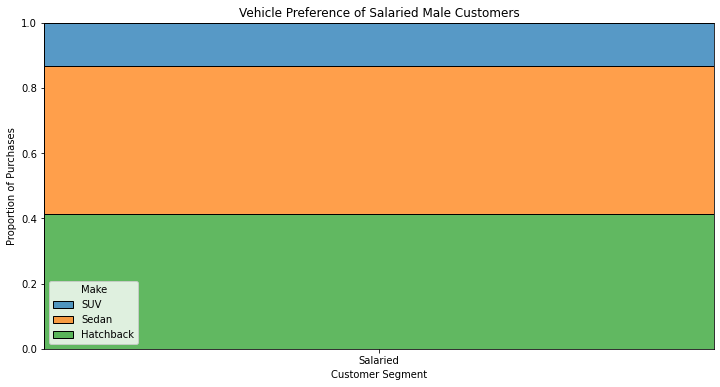

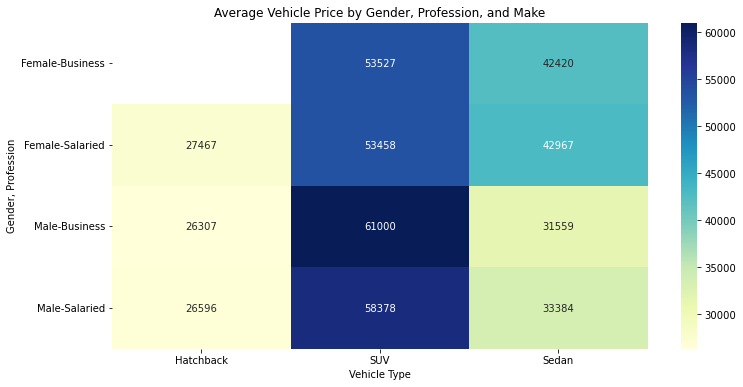

In [87]:
sns.histplot(data=salaried_male_df,x='Profession',hue='Make',multiple='fill',shrink=0.8)
plt.title('Vehicle Preference of Salaried Male Customers')
plt.ylabel('Proportion of Purchases')
plt.xlabel('Customer Segment')
plt.show()

price_pivot = austo_df.pivot_table(values='Price',index=['Gender', 'Profession'],columns='Make',aggfunc='mean')
sns.heatmap(price_pivot,annot=True,fmt=".0f",cmap='YlGnBu')
plt.title('Average Vehicle Price by Gender, Profession, and Make')
plt.ylabel('Gender, Profession')
plt.xlabel('Vehicle Type')
plt.show()


The data provides partial support for Sheldon Cooper’s claim that a salaried male is an easier target for an SUV sale compared to a Sedan sale. Within the salaried male segment, while Sedans are still commonly purchased, SUVs are bought at higher prices and generate more value per sale within this group. This indicates that focusing on SUVs for salaried male customers can lead to better revenue outcomes compared to targeting Sedans.

### 4. How does the amount spent on purchasing automobiles vary by gender? 

**Observation:**

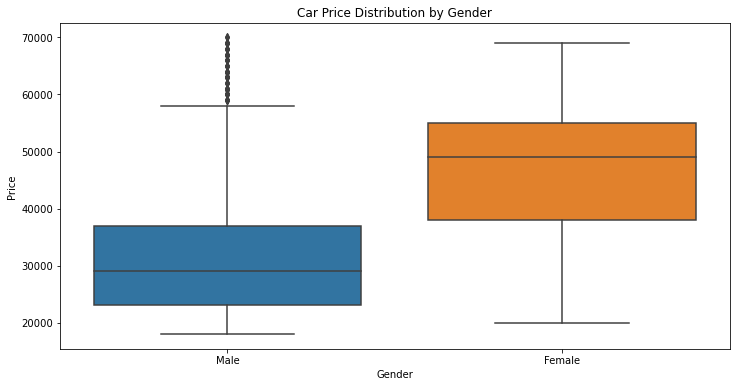

In [88]:
#Gender vs price:
sns.boxplot(data=austo_df, x='Gender', y='Price')
plt.title('Car Price Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Price')
plt.show()

Analysis of automobile purchase prices by gender indicates a significant difference in spending behavior. Female customers spend considerably more on automobile purchases compared to male customers, with both higher average and median prices. This suggests that female buyers tend to opt for higher-priced vehicles, while male buyers are more concentrated in lower price ranges.

### 5. How much money was spent on purchasing automobiles by individuals who took a personal loan? 

**Observation:**

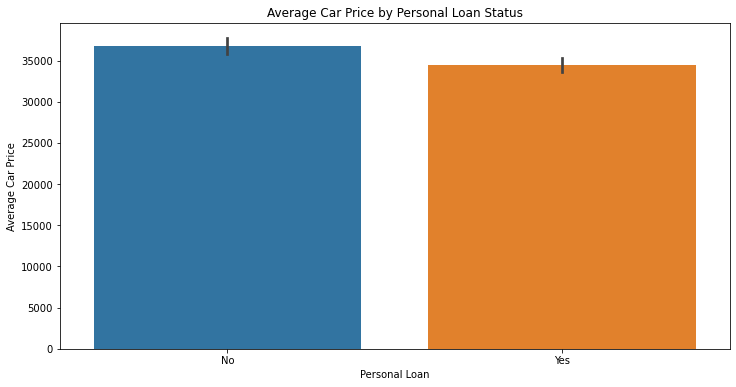

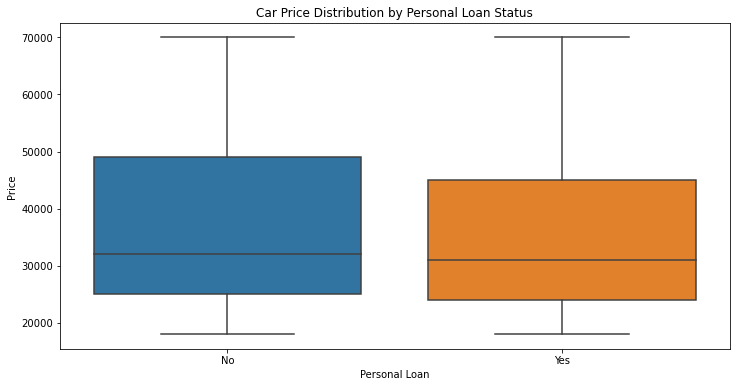

Personal_loan
No     28990000
Yes    27290000
Name: Price, dtype: int64

In [89]:
sns.barplot(data=austo_df, x='Personal_loan', y='Price')
plt.title('Average Car Price by Personal Loan Status')
plt.xlabel('Personal Loan')
plt.ylabel('Average Car Price')
plt.show()

sns.boxplot(data=austo_df, x='Personal_loan', y='Price')
plt.title('Car Price Distribution by Personal Loan Status')
plt.xlabel('Personal Loan')
plt.ylabel('Price')
plt.show()

austo_df.groupby('Personal_loan')['Price'].sum()


Analysis of automobile purchases based on personal loan status indicates that individuals who availed a personal loan spent approximately 25.7 million dollars on vehicle purchases. Although the average and median purchase prices for personal-loan customers are slightly lower than those for customers without loans, this group contributes a substantial share of overall automobile spending.

### 6. How does having a working partner influence the purchase of higher-priced cars? 

**Observation:**

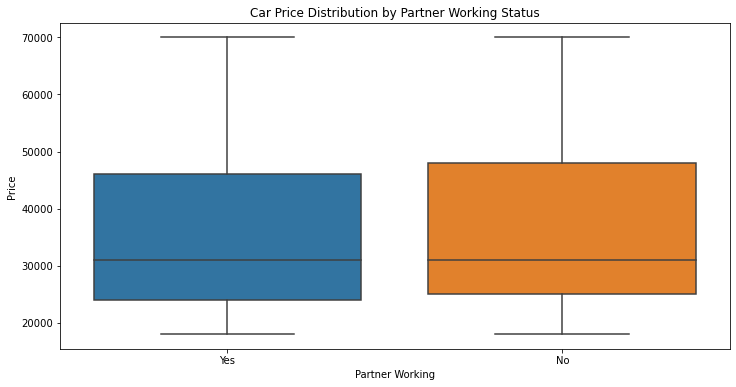

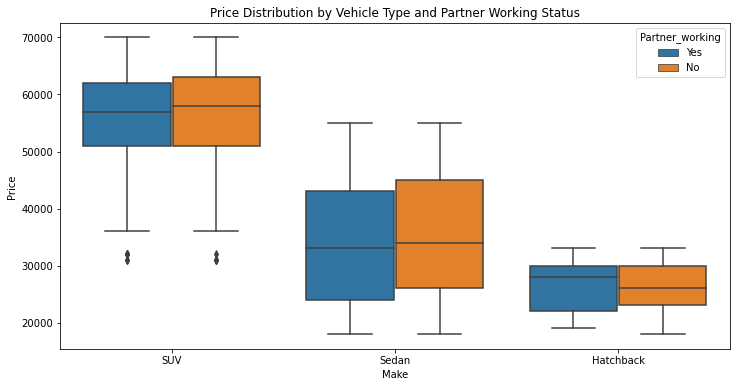

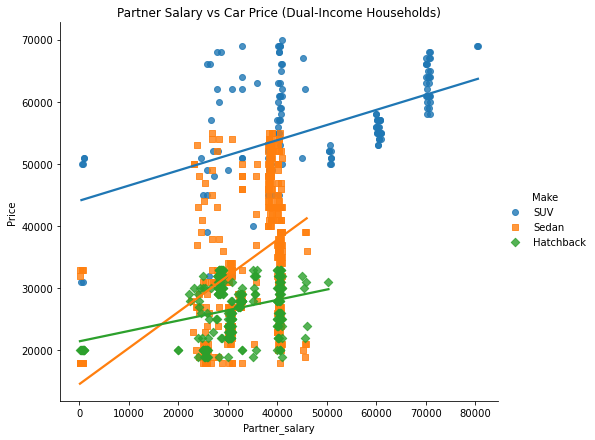

Partner_working
No     25668000
Yes    30612000
Name: Price, dtype: int64


Make,Hatchback,SUV,Sedan
Partner_working,,,
No,26323.843416,56173.611111,35354.166667
Yes,26614.617940,55496.732026,34082.125604


In [93]:
#Partner_working vs Price:

sns.boxplot(data=austo_df, x='Partner_working', y='Price')
plt.title('Car Price Distribution by Partner Working Status')
plt.xlabel('Partner Working')
plt.ylabel('Price')
plt.show()

sns.boxplot(data=austo_df, x='Make', y='Price', hue='Partner_working')
plt.title('Price Distribution by Vehicle Type and Partner Working Status')
plt.show()

dual_income_df = austo_df[austo_df['Partner_working'] == 'Yes']
sns.lmplot(data=dual_income_df,x='Partner_salary',y='Price',hue='Make', height=6,aspect=1.2,markers=['o', 's', 'D'], ci=None)
plt.title('Partner Salary vs Car Price (Dual-Income Households)')
plt.show()
dual_income_df[['Partner_salary', 'Price']].corr()

# Total spend by partner working status
partner_total_spend = (austo_df.groupby('Partner_working')['Price'].sum())
print(partner_total_spend)

austo_df.groupby(['Partner_working', 'Make'])['Price'].mean().unstack()


Analysis of automobile purchases indicates that having a working partner does not significantly increase the average or median price of vehicles purchased. Both single-income and dual-income households exhibit similar median spending levels. While partner working status alone does not materially increase average purchase price, higher partner salaries within dual-income households are strongly associated with the purchase of higher-priced vehicle types, particularly SUVs.